In [1]:
import faiss 
import numpy as np
import time 
import matplotlib.pyplot as plt 

In [2]:
BASE_DIR= '/Users/Damian/approximate-nearest-neighbor-graphs/Datasets/siftsmall'

<h2>Methods to read fvecs/ivecs Files</h2>

In [3]:
def read_fvecs(fname):
    data = np.fromfile(fname,dtype="int32")
    if data is None:
        raise ValueError("Not valida fvecs file")
    dim = data[0]
    assert data.shape%(dim+1) == 0, "Corrupted fvecs file"
    n = data.shape[0]//(dim+1)
    return data.reshape(n,dim+1)[:,1:].astype("float32")

def read_ivecs(fname):
    data = np.fromfile(fname,dtype='int32')
    if data is None:
        raise ValueError("Not valida ivecs file")
    dim = data[0]
    assert data.shape%(dim+1) == 0, "Corrupted ivecs file"
    n = data.shape[0]//(dim+1)
    return data.reshape(n,dim+1)[:,1:].astype("int32")

<h2>Reading and Implementing IndexFlatL2</h2>

In [4]:
#read data
import numpy as np
xb = read_fvecs(f"{BASE_DIR}/siftsmall_base.fvecs")
xq = read_fvecs(f"{BASE_DIR}/siftsmall_query.fvecs")
gt = read_ivecs(f"{BASE_DIR}/siftsmall_groundtruth.ivecs")

print(xb.shape)

(10000, 128)


In [5]:
def time_search(index, xq, k):
    start = time.time()
    D, I = index.search(xq, k)
    end = time.time()
    return D, I, end - start

In [6]:
#we will use IndexFlatL2 for exact search 
index = faiss.IndexFlatL2(xb.shape[1])
index.add(xb)
k =20
D,I,search_time = time_search(index, xq, k)
print(f"Exact search time for {xq.shape[0]} queries: {search_time:.4f} seconds")

Exact search time for 100 queries: 0.2358 seconds


In [7]:
for index, nn in enumerate(I[:5]):
    print(f"Query {index+1} nearest neighbors: {nn}")

Query 1 nearest neighbors: [  74 4181 2516 3613 4300 4152 2019 2553 4314 4060 9171 3780 3524 2808
 4353 1907 3295  463 1646  531]
Query 2 nearest neighbors: [ 839 1033 4060 4413 4314 4152 2553 9171 3524 3187 2075 2808 1907 9371
 3298 4429 3613 2607 1367  755]
Query 3 nearest neighbors: [2698 2256  879   12 5834  391  167 2593 2123 7059 9046 1837 4468 9895
 4266 9950 1817  415 2335  153]
Query 4 nearest neighbors: [2906 4269 4243 4062 2630 3061 2405  755  964  609 4270 1543 2734 1664
 3515 3336  462 7827 1292 3883]
Query 5 nearest neighbors: [3574 8630 3980 9365 4667 2623 4155 4547 2467  472 5834  827 4897  802
 1861 6506 1344 4259 3369 2980]


<h2>HNSW</h2>

In [8]:
index_hnsw = faiss.IndexHNSWFlat(xb.shape[1],16)
index_hnsw.efConstruction = 32
index_hnsw.add(xb)

<p>how many nodes does each layer has</p>

In [9]:
levels = faiss.vector_to_array(index_hnsw.hnsw.levels)
print(f"Total Layers (0-{int(levels.max())}): {int(levels.max())+1}")
for l in range(levels.max()+1):
    num_nodes = int((levels >= (l+1)).sum())
    print(f"Layer {l}: Number of nodes: {num_nodes}")

Total Layers (0-4): 5
Layer 0: Number of nodes: 10000
Layer 1: Number of nodes: 602
Layer 2: Number of nodes: 23
Layer 3: Number of nodes: 3
Layer 4: Number of nodes: 0


<p>calculating the queries using HNSW</p>

In [10]:
index_hnsw.hnsw.efSearch =48 
D_pred , I_pred, search_hnsw_time = time_search(index_hnsw, xq, k)
print(f"HNSW search time for {xq.shape[0]} queries: {search_hnsw_time:.4f} seconds")
for index, nn in enumerate(I_pred[:5]):
    print(f"Query {index+1} nearest neighbors (HNSW): {nn}")

HNSW search time for 100 queries: 0.0635 seconds
Query 1 nearest neighbors (HNSW): [  74 4181 2516 3613 4300 4152 2019 2553 4314 4060 9171 3780 3524 2808
 4353 1907 3295  463 1646  531]
Query 2 nearest neighbors (HNSW): [ 839 1033 4060 4413 4314 4152 2553 9171 3524 3187 2075 2808 1907 9371
 3298 4429 3613 2607 1367  531]
Query 3 nearest neighbors (HNSW): [2698 2256  879   12 5834  391  167 2593 2123 7059 9046 1837 4468 4266
 9950  415 2335  153 6347 5379]
Query 4 nearest neighbors (HNSW): [2906 4269 4243 4062 2630 3061 2405  755  964  609 4270 1543 2734 1664
 3515 3336  462 7827 1292 3883]
Query 5 nearest neighbors (HNSW): [3574 8630 3980 9365 4667 4155 4547 2467  827 4897  802 1861 6506 1344
 4259 3369 2980 1128 8230 2799]


<p>As we can see the time calculation of the queries using HNSW dropped dramatically</p>

<h2>Recall Calculation</h2>

In [11]:
def recall_at_k(I_true,I_pred,k):
    inter = 0
    for t,p in zip(I_true,I_pred):
        inter += len(set(t[:k]).intersection(p[:k]))
    return inter/(I_true.shape[0]*k)

In [12]:
recall = recall_at_k(I, I_pred, k)
print(f"Recall@{k} for HNSW: {recall:.4f}")

Recall@20 for HNSW: 0.9435


<p>As we can see the HNSW had approximately 95% based on the IndexFlatL2</p>

<h2>QPS calculation</h2>

In [13]:
def measure_qps(index,xq,k):
    start = time.time()
    D,I = index.search(xq,k)
    end = time.time()
    total_time = end-start
    qps = len(xq)/total_time
    return qps 

In [14]:
#TODO: Combine qps and recall 
def measure_qps_recall(index,xq,k,I_true=None,random_state=42):
    np.random.seed(random_state)
    start = time.time()
    D,I = index.search(xq,k)
    end = time.time()
    total_time = end-start
    qps = len(xq)/total_time
    if I_true is not None:
        recall = recall_at_k(I_true,I,k)
        return qps, recall
    return qps


In [15]:
print(f"Exact search QPS: {measure_qps(index_hnsw,xq,k):.2f} queries/second")

Exact search QPS: 3815.78 queries/second


In [16]:
def plot_qps_recall(results,title="QPS vs Recall",save_path=None):
    fig, ax = plt.subplots(figsize=(10,6))

    names = [r['name'] for r in results]
    qps = [r['qps'] for r in results]
    recall = [r['recall'] for r in results]

    #for a clean line plot
    sorted_indices = np.argsort(recall)
    recall = [recall[i] for i in sorted_indices]
    qps = [qps[i] for i in sorted_indices]
    names = [names[i] for i in sorted_indices]

    ax.plot(recall,qps, marker='o',linestyle ='--',alpha=0.7)
    for i, name in enumerate(names):
        ax.annotate(name, (recall[i], qps[i]), textcoords="offset points", xytext=(0,8), ha='center')
    ax.set_xlabel("Recall")
    ax.set_ylabel("Queries per Second (QPS)")
    ax.set_title(title)
    ax.grid(True,alpha=0.4)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)

    plt.show()

In [17]:
index_flat = faiss.IndexFlatL2(xb.shape[1])
index_flat.add(xb)
D_true, I_true = index_flat.search(xq, k)

In [18]:
results = []

for ef in [16,32,48,64,128,256]:
    index_hnsw.hnsw.efSearch = ef 
    qps , recall = measure_qps_recall(index_hnsw,xq,k,I_true)
    results.append({
        "name": f"HNSW efSearch={ef}",
        "qps": qps,
        "recall": recall
    })



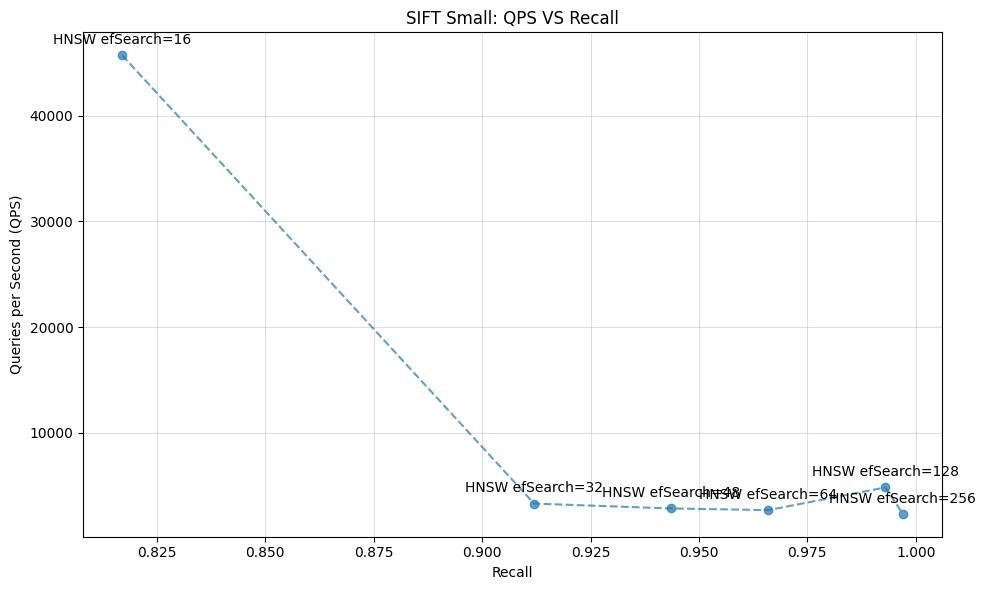

In [19]:
plot_qps_recall(results,title="SIFT Small: QPS VS Recall")


In [20]:
def sweep_hnsw(xb, xq, xb_for_index, I_true, ks=(1,5,10)):
    """
    Sweep HNSW across M, efConstruction, efSearch and return results list.
    Uses measure_qps_recall(...) to get qps and recall@max(ks).
    Also computes recall@k for each k in ks from a single search result.
    """
    results = []
    ks = tuple(sorted(ks))
    k_max = max(ks)

    M_values = [8, 16, 32, 48]
    efC_values = [16, 32, 64]
    efS_values = [8, 16, 32, 64, 128, 256]

    for M in M_values:
        for efC in efC_values:
            # create a fresh index for each (M, efC) to avoid accumulation
            idx = faiss.IndexHNSWFlat(xb_for_index.shape[1], M)
            idx.hnsw.efConstruction = efC

            # build time
            t0 = time.perf_counter()
            idx.add(xb_for_index)
            t1 = time.perf_counter()
            build_time = t1 - t0

            # optional: get level info if you want to store it
            # levels = faiss.vector_to_array(idx.hnsw.levels)

            for efS in efS_values:
                idx.hnsw.efSearch = efS

                # measure qps and recall@k_max using your provided function
                # measure_qps_recall returns (qps, recall) when I_true is provided
                qps_recall = measure_qps_recall(idx, xq, k_max, I_true=I_true)
                if isinstance(qps_recall, tuple):
                    qps, recall_at_kmax = qps_recall
                else:
                    # defensive: if function returned just qps (no I_true), set recall_at_kmax to None
                    qps = qps_recall
                    recall_at_kmax = None

                # run one search (no timing) to compute recalls for each k in ks
                D_search, I_search = idx.search(xq, k_max)

                # compute per-k recalls
                per_k_recalls = {}
                for k in ks:
                    per_k_recalls[f"recall@{k}"] = recall_at_k(I_true[:, :k], I_search[:, :k], k)

                # create a human-readable name for plotting
                name = f"M{M}_efC{efC}_efS{efS}"

                row = {
                    "name": name,
                    "M": M,
                    "efConstruction": efC,
                    "efSearch": efS,
                    "build_time": build_time,
                    "qps": qps,
                    # single recall value used for plotting (recall@k_max)
                    "recall": recall_at_kmax,
                }
                # add per-k recalls
                row.update(per_k_recalls)

                results.append(row)

    return results


In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from math import ceil

def plot_results_by_M(results, ks=(1,5,10,20), efS_log_x=False, figsize_per_row=(12,3.5), save_path=None):
    """
    Plot per-M panels:
      - left: recall@k curves vs efSearch (one line per efConstruction)
      - right: qps vs efSearch (one line per efConstruction)
    Args:
      results: list of dicts (as produced by your sweep_hnsw)
      ks: tuple of ks to plot (should match keys like 'recall@1' etc. present in results)
      efS_log_x: bool, whether to use log scale on x-axis (efSearch)
      figsize_per_row: tuple for (width, height) per row (one row per M)
      save_path: optional path to save the full figure (PNG/PDF)
    """
    if not results:
        raise ValueError("Empty results list")

    # Convert to DataFrame for easier grouping/slicing
    df = pd.DataFrame(results)

    # Ensure efSearch is numeric
    df['efSearch'] = df['efSearch'].astype(int)
    df['efConstruction'] = df['efConstruction'].astype(int)
    df['M'] = df['M'].astype(int)

    Ms = sorted(df['M'].unique())
    nrows = len(Ms)
    fig_w = figsize_per_row[0]
    fig_h = figsize_per_row[1] * nrows
    fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(fig_w, fig_h), squeeze=False)

    # Color/marker cycle
    prop_cycle = plt.rcParams['axes.prop_cycle'].by_key()
    colors = prop_cycle.get('color', None)
    markers = ['o','s','^','D','v','*','X','P']

    for r, M in enumerate(Ms):
        ax_recall = axes[r, 0]
        ax_qps = axes[r, 1]

        df_M = df[df['M'] == M].copy()
        efCs = sorted(df_M['efConstruction'].unique())

        # For consistent legend order, sort by efConstruction
        for i, efC in enumerate(efCs):
            df_line = df_M[df_M['efConstruction'] == efC].sort_values('efSearch')
            x = df_line['efSearch'].values
            color = colors[i % len(colors)] if colors else None
            marker = markers[i % len(markers)]

            # Plot recall lines for each k on the same left axis
            for k_idx, k in enumerate(ks):
                colname = f"recall@{k}"
                if colname not in df_line.columns:
                    continue
                # Slight offset for k lines so they are distinguishable per efC
                # Use different linestyles per k
                linestyle = ['-','--','-.',':'][k_idx % 4]
                label = f"efC={efC}" if k_idx==0 else None  # label only once per efC to avoid duplicates
                ax_recall.plot(x, df_line[colname].values,
                               label=label,
                               color=color,
                               marker=marker,
                               linestyle=linestyle,
                               alpha=0.9)

            # Plot QPS on right axis
            ax_qps.plot(x, df_line['qps'].values,
                        label=f"efC={efC} (build={df_line['build_time'].iloc[0]:.3f}s)",
                        color=color,
                        marker=marker,
                        linestyle='-',
                        alpha=0.9)

        # Left axis formatting (recall)
        ax_recall.set_title(f"M = {M} — Recall curves")
        ax_recall.set_xlabel("efSearch")
        ax_recall.set_ylabel("Recall")
        ax_recall.grid(True, alpha=0.35)
        # show legend for efConstruction only (we labeled only once per efC)
        ax_recall.legend(title="efConstruction", loc='lower right', fontsize='small')

        # Right axis formatting (qps)
        ax_qps.set_title(f"M = {M} — QPS")
        ax_qps.set_xlabel("efSearch")
        ax_qps.set_ylabel("Queries per second (QPS)")
        ax_qps.grid(True, alpha=0.35)
        ax_qps.legend(title="efC (build time)", loc='upper right', fontsize='small')

        if efS_log_x:
            ax_recall.set_xscale('log', base=2)
            ax_qps.set_xscale('log', base=2)

        # make x ticks integer and sorted
        efS_values = sorted(df_M['efSearch'].unique())
        ax_recall.set_xticks(efS_values)
        ax_qps.set_xticks(efS_values)

        # tighten y-limits for recall for nicer view
        ax_recall.set_ylim(0.0, 1.02)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')

    plt.show()


{'name': 'M8_efC16_efS8', 'M': 8, 'efConstruction': 16, 'efSearch': 8, 'build_time': 0.3433432689998881, 'qps': 56141.13237853032, 'recall': 0.549, 'recall@1': 0.73, 'recall@5': 0.642, 'recall@10': 0.621, 'recall@20': 0.549}
{'name': 'M8_efC16_efS16', 'M': 8, 'efConstruction': 16, 'efSearch': 16, 'build_time': 0.3433432689998881, 'qps': 2244.5637224734432, 'recall': 0.669, 'recall@1': 0.79, 'recall@5': 0.732, 'recall@10': 0.722, 'recall@20': 0.669}
{'name': 'M8_efC16_efS32', 'M': 8, 'efConstruction': 16, 'efSearch': 32, 'build_time': 0.3433432689998881, 'qps': 2635.2420803960745, 'recall': 0.783, 'recall@1': 0.86, 'recall@5': 0.832, 'recall@10': 0.82, 'recall@20': 0.783}
{'name': 'M8_efC16_efS64', 'M': 8, 'efConstruction': 16, 'efSearch': 64, 'build_time': 0.3433432689998881, 'qps': 2523.466416383895, 'recall': 0.873, 'recall@1': 0.93, 'recall@5': 0.908, 'recall@10': 0.895, 'recall@20': 0.873}
{'name': 'M8_efC16_efS128', 'M': 8, 'efConstruction': 16, 'efSearch': 128, 'build_time': 0.34

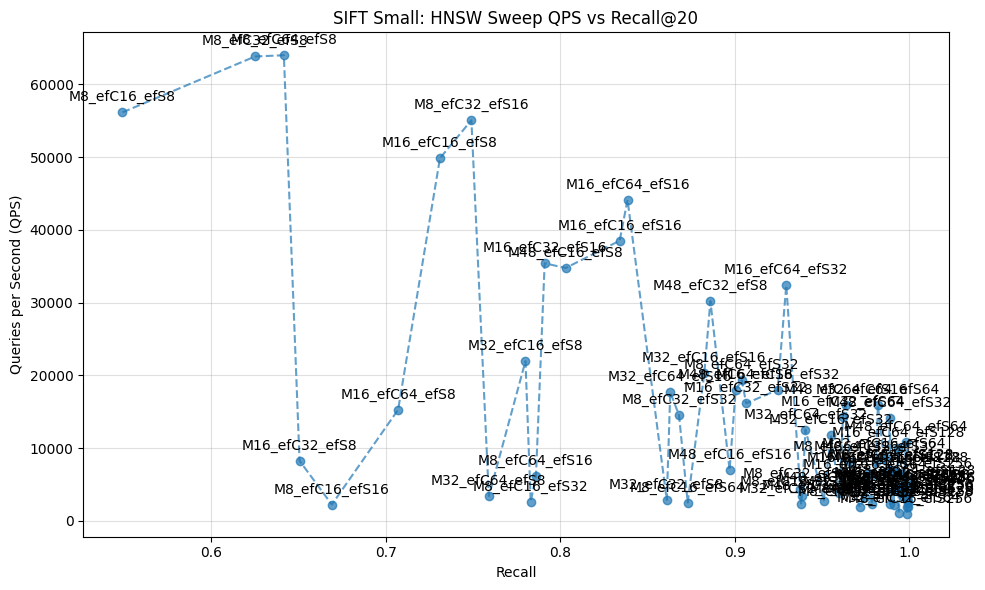

In [21]:
new_result = sweep_hnsw(xb, xq, xb, I_true, ks=(1,5,10,20))
for res in new_result:
    print(res)
plot_qps_recall(new_result, title="SIFT Small: HNSW Sweep QPS vs Recall@20")

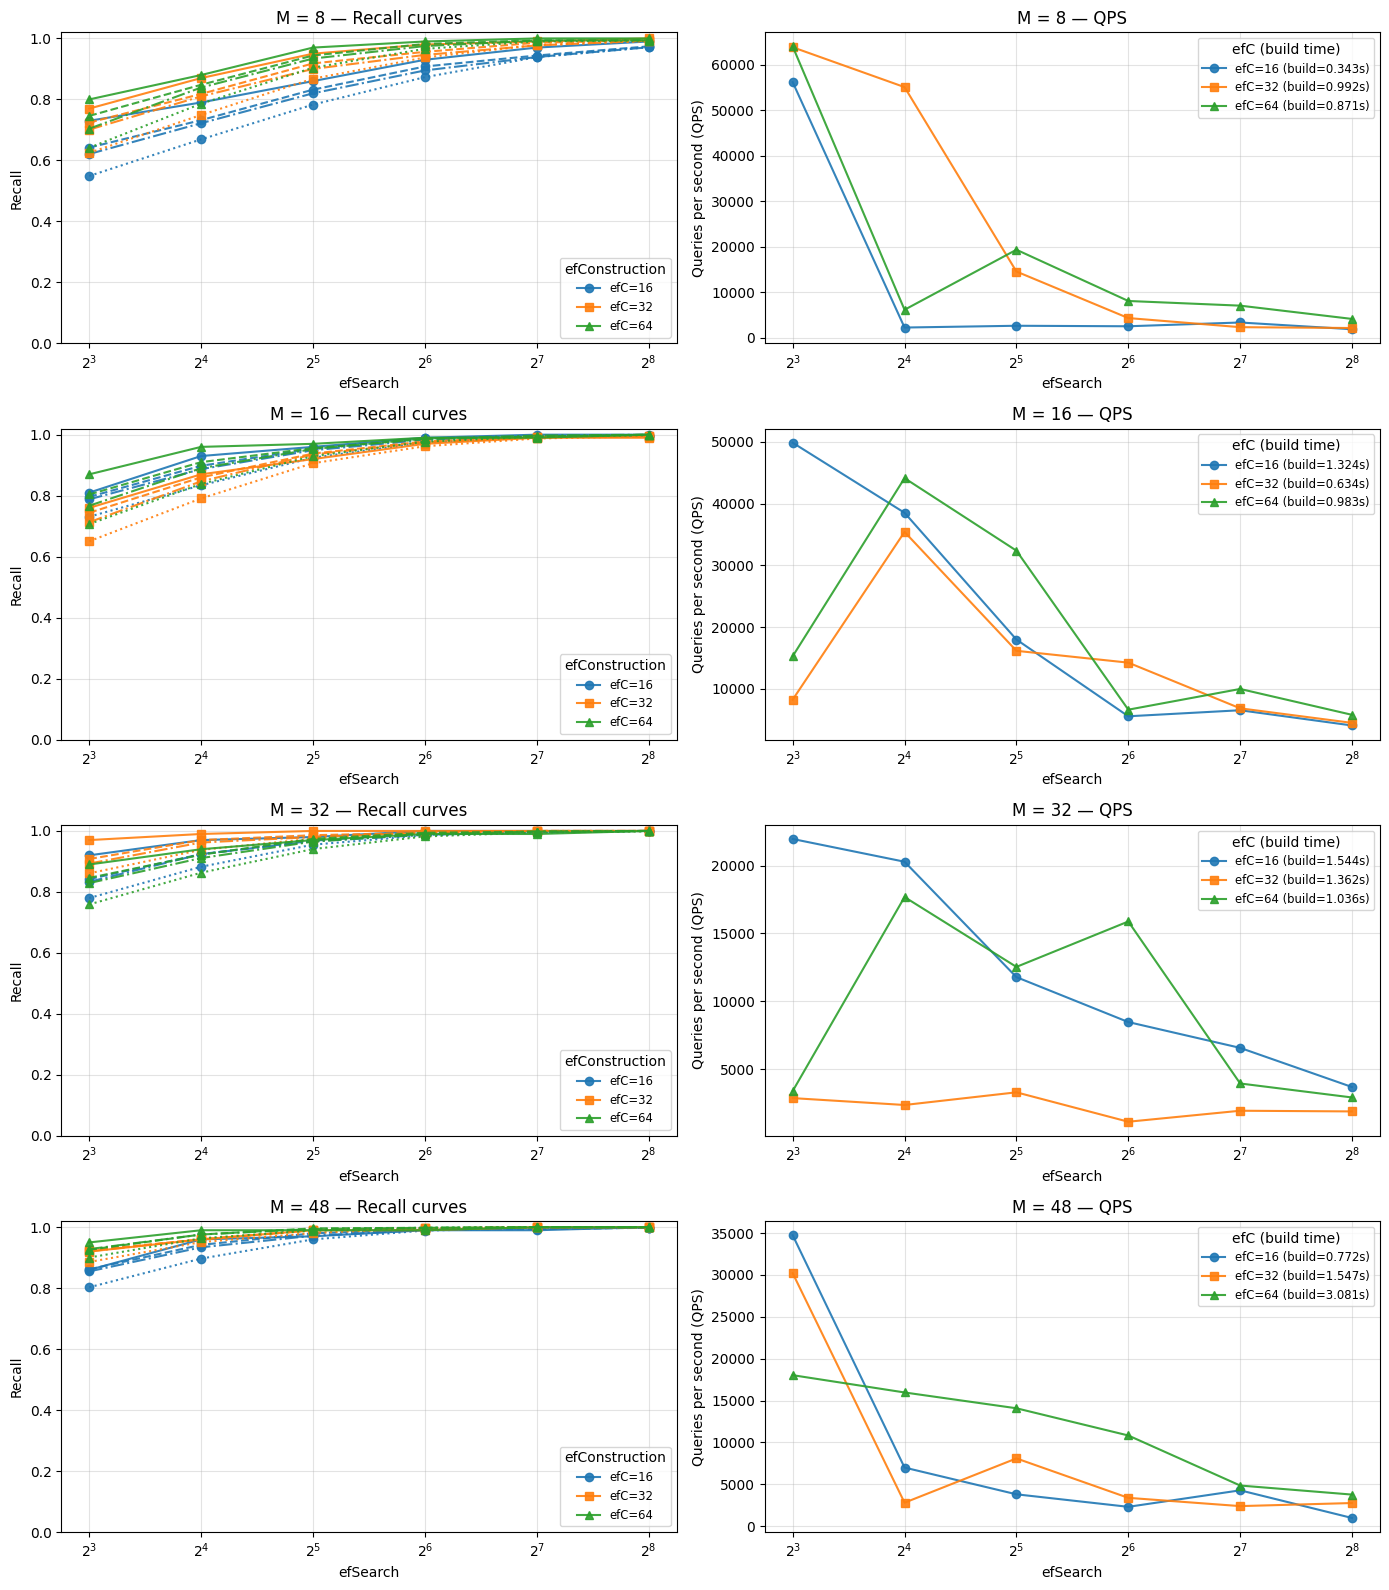

In [23]:
plot_results_by_M(new_result, ks=(1,5,10,20), efS_log_x=True, figsize_per_row=(14,4), save_path=None)